# Import Statements

In [27]:
import numpy as np
import pandas as pd
from typing import List, Dict
import matplotlib.pyplot as plt 
import time
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from nba_api.stats.endpoints import leaguedashplayerstats
import unicodedata  

np.random.seed(30)



# Getting Data
To conduct my analysis, I collected data from 2010-2011 up until 2024-2025 for my training data by using the nba_api. The data I collected was a comprehensive review of player data, including performance metrics like points, assists, rebounds, steals, and shooting efficiency (amongst others). When running my code, I found there was an issue that no MVP was found for the 2020-21, 2021-22, and 2023-24 seasons. Curious as to why, I discovered that Nikola Jokic, the MVP that year, had an accent mark in his name, and my code could not handle that. As a result, I created a function that converted all names to ASCII-only Uppercase letters. In case of any timeouts or exceptions, in my code, I wrote some try-catch blocks to ensure the code ran properly. 

In [61]:
TRAIN_SEASONS: List[str] = [
    f"{year}-{str(year + 1)[-2:]}" for year in range(2010, 2025)
]

PREDICTION_SEASON: str = "2025-26"

mvp_by_season: Dict[str, str] = {
    "2010-11": "DERRICK ROSE",
    "2011-12": "LEBRON JAMES",
    "2012-13": "LEBRON JAMES",
    "2013-14": "KEVIN DURANT",
    "2014-15": "STEPHEN CURRY",
    "2015-16": "STEPHEN CURRY",
    "2016-17": "RUSSELL WESTBROOK",
    "2017-18": "JAMES HARDEN",
    "2018-19": "GIANNIS ANTETOKOUNMPO",
    "2019-20": "GIANNIS ANTETOKOUNMPO",
    "2020-21": "NIKOLA JOKIC",
    "2021-22": "NIKOLA JOKIC",
    "2022-23": "JOEL EMBIID",
    "2023-24": "NIKOLA JOKIC",
    "2024-25": "SHAI GILGEOUS-ALEXANDER",
}

#Clean Names (For Nikola Jokic primarily)
def to_ascii_upper(s: str) -> str:
    if not isinstance(s, str):
        return ""
    normalized = unicodedata.normalize("NFKD", s)
    ascii_bytes = normalized.encode("ascii", "ignore")
    ascii_str = ascii_bytes.decode("ascii")
    return ascii_str.upper().strip()

# Clean MVP dict
mvp_by_season_clean: Dict[str, str] = {
    season: to_ascii_upper(name) for season, name in mvp_by_season.items()
}

#Fetch Player data per-season from nba_api
def get_league_dash_player_stats(season: str, per_mode: str = "PerGame", sleep_seconds: float = 0.5, max_retries: int = 3) -> pd.DataFrame:
    for attempt in range(1, max_retries + 1):
        try:
            time.sleep(sleep_seconds)  # be polite to the API
            stats_endpoint = leaguedashplayerstats.LeagueDashPlayerStats(
                season=season,
                per_mode_detailed=per_mode,
                season_type_all_star="Regular Season",
                timeout=10,  # seconds; less than default 30
            )
            df = stats_endpoint.get_data_frames()[0]
            df["SEASON"] = season
            return df

        except (ReadTimeout, ConnectionError) as e:
            print(
                f"Timeout/connection error on {season} (attempt {attempt}/{max_retries}): {e}"
            )
            # simple backoff
            time.sleep(1.0 * attempt)

    print(f"Giving up on season {season} after {max_retries} attempts.")
    # Return empty df so caller can skip this season
    return pd.DataFrame()

#Build Dataset
def build_historical_dataset(seasons: List[str]) -> pd.DataFrame:
    """
    Pull data from NBA API for all seasons, stack into a single DataFrame,
    and attach MVP labels (is_mvp), with accents stripped for ease.
    """
    all_seasons = []

    for season in seasons:
        print(f"Fetching stats for {season} ...")
        df_season = get_league_dash_player_stats(season, per_mode="PerGame")

        if df_season.empty:
            print(f"WARNING: No data returned for season {season}. Skipping.")
            continue

        # Strip accents & uppercase player names (vectorized, fast)
        df_season["PLAYER_NAME_CLEAN"] = (
            df_season["PLAYER_NAME"]
            .str.normalize("NFKD")
            .str.encode("ascii", "ignore")
            .str.decode("ascii")
            .str.upper()
            .str.strip()
        )

        if season in mvp_by_season_clean:
            mvp_clean = mvp_by_season_clean[season]
            df_season["is_mvp"] = (
                df_season["PLAYER_NAME_CLEAN"] == mvp_clean
            ).astype(int)

            match_count = df_season["is_mvp"].sum()
            if match_count != 1:
                print(
                    f"WARNING: Season {season} MVP match count is "
                    f"{match_count} (expected 1)."
                )
        else:
            print(f"WARNING: No MVP entry for season {season}. All labels = 0.")
            df_season["is_mvp"] = 0

        all_seasons.append(df_season)

    if not all_seasons:
        raise ValueError("No season data retrieved. Check API or season list.")

    full_df = pd.concat(all_seasons, ignore_index=True)
    return full_df

historical_df = build_historical_dataset(TRAIN_SEASONS)

print(
    historical_df[
        ["SEASON", "PLAYER_NAME", "PLAYER_NAME_CLEAN", "is_mvp"]
    ].head()
)
print("Total rows:", len(historical_df))
print("Total MVP rows (positives):", historical_df["is_mvp"].sum())

historical_df.head(n = 2000)

Fetching stats for 2010-11 ...
Fetching stats for 2011-12 ...
Fetching stats for 2012-13 ...
Fetching stats for 2013-14 ...
Fetching stats for 2014-15 ...
Fetching stats for 2015-16 ...
Fetching stats for 2016-17 ...
Fetching stats for 2017-18 ...
Fetching stats for 2018-19 ...
Fetching stats for 2019-20 ...
Fetching stats for 2020-21 ...
Fetching stats for 2021-22 ...
Fetching stats for 2022-23 ...
Fetching stats for 2023-24 ...
Fetching stats for 2024-25 ...
    SEASON    PLAYER_NAME PLAYER_NAME_CLEAN  is_mvp
0  2010-11       AJ Price          AJ PRICE       0
1  2010-11   Aaron Brooks      AARON BROOKS       0
2  2010-11     Aaron Gray        AARON GRAY       0
3  2010-11       Acie Law          ACIE LAW       0
4  2010-11  Al Harrington     AL HARRINGTON       0
Total rows: 7759
Total MVP rows (positives): 15


,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT,SEASON,PLAYER_NAME_CLEAN,is_mvp
0,201985,AJ Price,AJ,1610612754,IND,24.0,50,22,28,0.440,...,240,161,274,224,27,264,1,2010-11,AJ PRICE,0
1,201166,Aaron Brooks,Aaron,1610612756,PHX,26.0,59,26,33,0.441,...,132,377,179,154,27,164,2,2010-11,AARON BROOKS,0
2,201189,Aaron Gray,Aaron,1610612740,NOH,26.0,41,21,20,0.512,...,362,145,326,154,27,332,1,2010-11,AARON GRAY,0
3,201151,Acie Law,Acie,1610612744,GSW,26.0,51,20,31,0.392,...,321,368,335,224,27,340,2,2010-11,ACIE LAW,0
4,1733,Al Harrington,Al,1610612743,DEN,31.0,73,45,28,0.616,...,137,97,176,181,27,156,1,2010-11,AL HARRINGTON,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,201565,Derrick Rose,Derrick,1610612741,CHI,26.0,51,33,18,0.647,...,28,77,71,104,21,57,1,2014-15,DERRICK ROSE,0
1996,202682,Derrick Williams,Derrick,1610612758,SAC,24.0,74,27,47,0.365,...,199,429,284,193,21,264,1,2014-15,DERRICK WILLIAMS,0
1997,2734,Devin Harris,Devin,1610612742,DAL,32.0,76,45,31,0.592,...,187,121,200,252,21,204,1,2014-15,DEVIN HARRIS,0
1998,203906,Devyn Marble,Devyn,1610612753,ORL,22.0,16,3,13,0.188,...,431,287,398,252,21,405,1,2014-15,DEVYN MARBLE,0


The cell below just verifies that Nikola Jokic was present in the dataset and that there was proper functionality in my helper function. 

In [4]:
Jokic_Rows = (
    historical_df["PLAYER_NAME"].str.contains("Nikola", case=False, na=False)
    & historical_df["PLAYER_NAME"].str.contains("Jok", case=False, na=False)
)

historical_df[Jokic_Rows]


,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,...,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,TEAM_COUNT,SEASON,PLAYER_NAME_CLEAN,is_mvp
2720,203999,Nikola Jokić,Nikola,1610612743,DEN,21.0,80,31,49,0.388,...,151,117,97,41,25,112,1,2015-16,NIKOLA JOKIC,0
3201,203999,Nikola Jokić,Nikola,1610612743,DEN,22.0,73,37,36,0.507,...,51,29,26,14,4,32,1,2016-17,NIKOLA JOKIC,0
3732,203999,Nikola Jokić,Nikola,1610612743,DEN,23.0,75,43,32,0.573,...,37,28,12,11,4,13,1,2017-18,NIKOLA JOKIC,0
4263,203999,Nikola Jokić,Nikola,1610612743,DEN,24.0,80,53,27,0.663,...,32,44,9,6,2,13,1,2018-19,NIKOLA JOKIC,0
4800,203999,Nikola Jokić,Nikola,1610612743,DEN,25.0,73,46,27,0.630,...,37,55,15,7,2,16,1,2019-20,NIKOLA JOKIC,0
5333,203999,Nikola Jokić,Nikola,1610612743,DEN,26.0,72,47,25,0.653,...,13,20,1,1,2,3,1,2020-21,NIKOLA JOKIC,1
5923,203999,Nikola Jokić,Nikola,1610612743,DEN,27.0,74,46,28,0.622,...,10,14,1,1,1,1,1,2021-22,NIKOLA JOKIC,1
6478,203999,Nikola Jokić,Nikola,1610612743,DEN,28.0,69,48,21,0.696,...,25,1,3,2,1,4,1,2022-23,NIKOLA JOKIC,0
7052,203999,Nikola Jokić,Nikola,1610612743,DEN,29.0,79,55,24,0.696,...,12,1,3,2,2,4,1,2023-24,NIKOLA JOKIC,1
7613,203999,Nikola Jokić,Nikola,1610612743,DEN,30.0,70,46,24,0.657,...,3,3,1,2,1,1,1,2024-25,NIKOLA JOKIC,0


# Feature Selection
The code below shows the features I selected when looking for a Player's MVP Status. The features I selected varied from team success (Wins, Losses, Win%), to their offensive capabilities and efficiencies (points, assists, rebounds, FG%). I used the individual player statistics to ensure that the player was contributing heavily to their team's success, but I also included the success of the player's team as since 1980, no MVP had failed to make the Postseason. The most recent MVP to not make the playoffs was Kareem Abdul-Jabbar in 1976 when the Lakers went 40-42. 

Mullin, Eric. “How Many Times Has the NBA MVP Lost in the First Round of the Playoffs?” NBC 5 Dallas-Fort Worth, NBC 5 Dallas-Fort Worth, 28 Apr. 2022, www.nbcdfw.com/news/sports/nba-playoffs-how-many-times-has-the-mvp-lost-in-the-first-round/2953018/#:~:text=Finally%2C%20it%20should%20be%20mentioned%20that%20there,after%20finishing%20with%20a%20losing%2040%2D42%20record. 

In [5]:
candidate_feature_cols = [
    "GP",
    "W",
    "L",
    "W_PCT",
    "MIN",
    "PTS",
    "REB",
    "AST",
    "STL",
    "BLK",
    "TOV",
    "FG_PCT",
    "FG3_PCT",
    "FT_PCT",
    "PLUS_MINUS",
]

feature_cols = [
    col for col in candidate_feature_cols if col in historical_df.columns
]

print("Using feature columns:", feature_cols)

historical_df = historical_df.dropna(subset=feature_cols + ["is_mvp"])

X = historical_df[feature_cols].copy()
y = historical_df["is_mvp"].astype(int).values
groups = historical_df["SEASON"].values

print("X shape:", X.shape)
print("MVP positives:", y.sum())


Using feature columns: ['GP', 'W', 'L', 'W_PCT', 'MIN', 'PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'PLUS_MINUS']
X shape: (7759, 15)
MVP positives: 15


The code below separates my data into feature (predictor) columns and the response vector indicating whether the player is an MVP or not. 

In [6]:
historical_df = historical_df.dropna(subset=feature_cols + ["is_mvp"])

X = historical_df[feature_cols].copy()
y = historical_df["is_mvp"].astype(int).values
groups = historical_df["SEASON"].values

# MVP Season Ranks
I wanted to go beyond just predicting if a player would be MVP, and see how MVPs perform in their incredible seasons. The code below helps me do just that. The code adds a players ranking amongst their NBA peers in the seasons they won MVP, including their average points, rebounds, and assists, and their ranks in each of these categories as well. 

In [65]:
# Add per-season ranks for PTS, AST, REB 
stats_to_rank = {
    "PTS": "rank_pts",
    "AST": "rank_ast",
    "REB": "rank_reb",
}

for stat_col, rank_col in stats_to_rank.items():
    if stat_col in historical_df.columns:
        historical_df[rank_col] = (
            historical_df
            .groupby("SEASON")[stat_col]
            .rank(ascending=False, method="min")
        )

# MVP-only subset 
mvp_df = historical_df[historical_df["is_mvp"] == 1].copy()

print("MVP rows with ranks:")
print(
    mvp_df[
        ["SEASON", "PLAYER_NAME_CLEAN", "PTS", "AST", "REB",
         "rank_pts", "rank_ast", "rank_reb"]
    ].sort_values("SEASON")
)


MVP rows with ranks:
       SEASON        PLAYER_NAME_CLEAN   PTS   AST   REB  rank_pts  rank_ast  \
124   2010-11             DERRICK ROSE  25.0   7.7   4.1       7.0      10.0   
757   2011-12             LEBRON JAMES  27.1   6.2   7.9       3.0      17.0   
1226  2012-13             LEBRON JAMES  26.8   7.3   8.0       4.0      11.0   
1664  2013-14             KEVIN DURANT  32.0   5.5   7.4       1.0      31.0   
2316  2014-15            STEPHEN CURRY  23.8   7.7   4.3       8.0       7.0   
2794  2015-16            STEPHEN CURRY  30.1   6.7   5.4       1.0      11.0   
3252  2016-17        RUSSELL WESTBROOK  31.6  10.4  10.7       1.0       3.0   
3553  2017-18             JAMES HARDEN  30.4   8.8   5.4       1.0       4.0   
4054  2018-19    GIANNIS ANTETOKOUNMPO  27.7   5.9  12.5       3.0      26.0   
4583  2019-20    GIANNIS ANTETOKOUNMPO  29.5   5.6  13.6       5.0      28.0   
5333  2020-21             NIKOLA JOKIC  26.4   8.3  10.8      11.0       7.0   
5923  2021-22      

As mentioned above, I wanted to show the performance of the MVPs and see what the numbers truly looked like for an MVP to win. This code visualizes the data, showing that in the past 15 years, players have scored an average PPG of roughly 29, while having about 7 APG and 9 RPG. It is clear that it is more important for a player to be more well-rounded than a pure scorer, which may lend the MVP to be an award more frequently won by forwards or centers rather than guards (although the split between guards and other positions winning MVP is about 40% guards, 60% other in the past 15 years). 

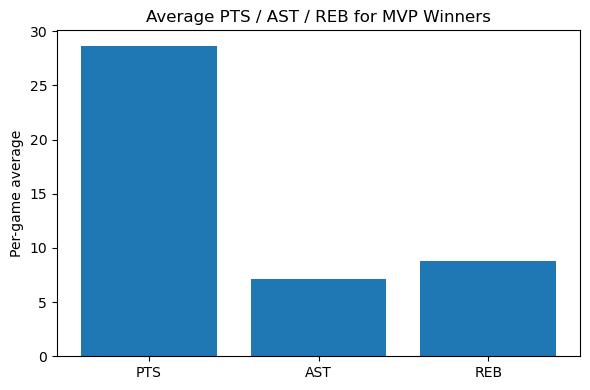

Average per-game stats for MVPs:
PTS    28.646667
AST     7.173333
REB     8.766667
dtype: float64


In [29]:
# Average stats for MVP winners
mvp_means = mvp_df[["PTS", "AST", "REB"]].mean()

plt.figure(figsize=(6, 4))
plt.bar(mvp_means.index, mvp_means.values)
plt.ylabel("Per-game average")
plt.title("Average PTS / AST / REB for MVP Winners")
plt.tight_layout()
plt.show()

print("Average per-game stats for MVPs:")
print(mvp_means)


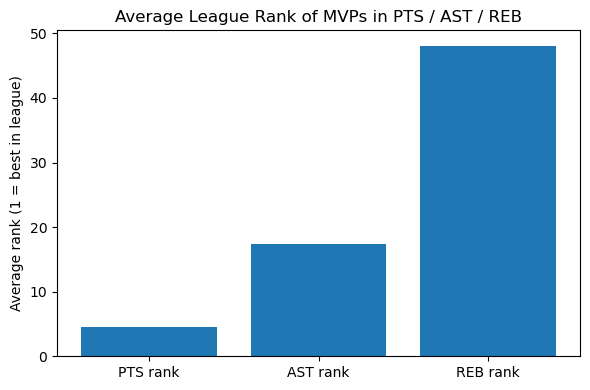

Average ranks for MVPs:
rank_pts     4.533333
rank_ast    17.333333
rank_reb    48.066667
dtype: float64


In [31]:
# Average ranks for MVP winners
rank_cols = ["rank_pts", "rank_ast", "rank_reb"]
mvp_rank_means = mvp_df[rank_cols].mean()

plt.figure(figsize=(6, 4))
plt.bar(["PTS rank", "AST rank", "REB rank"], mvp_rank_means.values)
plt.ylabel("Average rank (1 = best in league)")
plt.title("Average League Rank of MVPs in PTS / AST / REB")
plt.tight_layout()
plt.show()

print("Average ranks for MVPs:")
print(mvp_rank_means)


# Modeling
The code below shows how the models were created for this project. I used 3 different types of models: linear and logistic regression, and a Random Forest classifier. I used these 3 models because they each had different strengths. The linear model, for example, works better as a baseline, while the logistic regression excels at binary classification, which is the problem we are trying to solve here. The Random Forest model works better at non-linear prediction, which this task ultimately requires, as no two MVPs are built the same. In my modeling, I used a StandardScaler to make sure that the scales of each feature did not dominate the model (for example, points ranging from 0-35 would seem to have more impact than assists ranging from 0-15 because of the scale). By using the StandardScaler, all predictor variables were put on a roughly equal scale.

In [7]:
# Linear regression (linear probability model)
linreg_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)

# Logistic regression
logreg_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                solver="lbfgs",
            ),
        ),
    ]
)

# Random forest
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=30,
    class_weight="balanced",
    n_jobs=-1,
)


# Modeling Continued 
This area of the code goes through and uses GroupKFold to train the model using all the seasons except for one, and validates the model on the one season that is left out. This allows us to measure the perofrmance of our model, and cross-validate it across many seasons to avoid overfitting. As we can see, the models perform very well, with AUROC scores hovering around .99 for the most part. This means that our model is very successful at choosing which players are likely to win MVP. 

In [45]:
#Model Evaluation
from sklearn.metrics import roc_curve, precision_recall_curve

def evaluate_models_cv_return(
    X, y, groups,
    linreg_pipe, logreg_pipe, rf_model,
    n_splits=5
):
    gkf = GroupKFold(n_splits=n_splits)

    oof_preds = {
        "linreg": np.zeros(len(y)),
        "logreg": np.zeros(len(y)),
        "rf": np.zeros(len(y))
    }

    roc_data = {"linreg": [], "logreg": [], "rf": []}
    pr_data = {"linreg": [], "logreg": [], "rf": []}

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups), 1):
        print(f"\n=== Fold {fold} ===")
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Linear Regression
        linreg_pipe.fit(X_train, y_train)
        p_lin = np.clip(linreg_pipe.predict(X_val), 0, 1)
        oof_preds["linreg"][val_idx] = p_lin
        roc_data["linreg"].append(roc_curve(y_val, p_lin))
        pr_data["linreg"].append(precision_recall_curve(y_val, p_lin))

        # Logistic Regression
        logreg_pipe.fit(X_train, y_train)
        p_log = logreg_pipe.predict_proba(X_val)[:, 1]
        oof_preds["logreg"][val_idx] = p_log
        roc_data["logreg"].append(roc_curve(y_val, p_log))
        pr_data["logreg"].append(precision_recall_curve(y_val, p_log))

        # Random Forest
        rf_model.fit(X_train, y_train)
        p_rf = rf_model.predict_proba(X_val)[:, 1]
        oof_preds["rf"][val_idx] = p_rf
        roc_data["rf"].append(roc_curve(y_val, p_rf))
        pr_data["rf"].append(precision_recall_curve(y_val, p_rf))

        # Per-fold metrics
        print("Linear  AUROC:", roc_auc_score(y_val, p_lin))
        print("LogReg  AUROC:", roc_auc_score(y_val, p_log))
        print("RF      AUROC:", roc_auc_score(y_val, p_rf))

    # Final metrics
    print("\n=== OVERALL METRICS ===")
    for model in ["linreg", "logreg", "rf"]:
        auc = roc_auc_score(y, oof_preds[model])
        ap = average_precision_score(y, oof_preds[model])
        print(f"{model.upper()}: AUROC={auc:.4f}, AUPRC={ap:.4f}")

    return oof_preds, roc_data, pr_data

oof_preds, roc_data, pr_data = evaluate_models_cv_return(
    X, y, groups,
    linreg_pipe, logreg_pipe, rf_model
)



=== Fold 1 ===
Linear  AUROC: 0.9987154784842647
LogReg  AUROC: 0.9978591308071078
RF      AUROC: 0.8283022907300363

=== Fold 2 ===
Linear  AUROC: 0.9974076474400518
LogReg  AUROC: 0.9995679412400086
RF      AUROC: 0.9956794124000864

=== Fold 3 ===
Linear  AUROC: 0.991381167851756
LogReg  AUROC: 0.9965524671407024
RF      AUROC: 0.9980607627666451

=== Fold 4 ===
Linear  AUROC: 0.9982817869415808
LogReg  AUROC: 0.9974226804123711
RF      AUROC: 0.9974226804123711

=== Fold 5 ===
Linear  AUROC: 0.997411003236246
LogReg  AUROC: 0.9976267529665588
RF      AUROC: 0.9997842502696872

=== OVERALL METRICS ===
LINREG: AUROC=0.9968, AUPRC=0.3886
LOGREG: AUROC=0.9972, AUPRC=0.4869
RF: AUROC=0.9634, AUPRC=0.3321


# Model Performance
This code allows us to look at how the model performs by establishing some custom-made evaluators. It looks at where the model ranks the true MVPs for each season. Hits_at_X shows if the MVP was found in the top X players ranked by the model. MRR is the Mean MVP reciprocal rank, and is another evaluator for seeing where the true MVP ranks. It includes values from 0 to 1 inclusive, and the performance is better the higher the value is. NDCG is a measure to see how good the ranking is overall, except this gives a bit more leniency to if the MVP was put near the top, rather than if they were the top pick (as MRR is more harsh on this). 

In [77]:
def ranking_metrics(df, prob_column="prob_rf"):

    seasons = df["SEASON"].unique()
    
    ranks = []
    hits_at_1 = 0
    hits_at_3 = 0
    hits_at_5 = 0
    hits_at_10 = 0
    mrr_list = []
    ndcg_list = []

    for season in seasons:
        temp = df[df["SEASON"] == season].copy()
        temp = temp.sort_values(prob_column, ascending=False)

        # Get rank of MVP (1 = best)
        temp["rank"] = range(1, len(temp) + 1)
        mvp_row = temp[temp["is_mvp"] == 1]

        if len(mvp_row) == 0:
            continue  # Skip seasons without MVP label

        mvp_rank = int(mvp_row["rank"].iloc[0])
        ranks.append(mvp_rank)

        # Top-k accuracy
        if mvp_rank == 1:
            hits_at_1 += 1
        if mvp_rank <= 3:
            hits_at_3 += 1
        if mvp_rank <= 5:
            hits_at_5 += 1
        if mvp_rank <= 10:
            hits_at_10 += 1

        # Mean Reciprocal Rank (MRR)
        mrr_list.append(1.0 / mvp_rank)

        # NDCG (discounted gain)
        ndcg_list.append(1 / np.log2(mvp_rank + 1))

    # Summaries
    total_seasons = len(seasons)

    return {
        "avg_rank": np.mean(ranks),
        "mrr": np.mean(mrr_list),
        "ndcg": np.mean(ndcg_list),
        "hit_at_1": hits_at_1 / total_seasons,
        "hit_at_3": hits_at_3 / total_seasons,
        "hit_at_5": hits_at_5 / total_seasons,
        "hit_at_10": hits_at_10 / total_seasons,
        "ranks": ranks
    }


In [79]:
results = {}

for model_name, prob_column in [
    ("Linear", "prob_linreg"),
    ("Logistic", "prob_logreg"),
    ("Random Forest", "prob_rf"),
]:
    df_eval = historical_df.copy()
    df_eval[prob_column] = linreg_pipe.predict(X).clip(0,1) if "linreg" in prob_column else \
                           logreg_pipe.predict_proba(X)[:,1] if "logreg" in prob_column else \
                           rf_model.predict_proba(X)[:,1]

    print(f"\n=== Ranking Metrics for {model_name} ===")
    metrics = ranking_metrics(df_eval, prob_column=prob_column)
    results[model_name] = metrics

    for k, v in metrics.items():
        if k != "ranks":
            print(f"{k}: {v:.4f}")



=== Ranking Metrics for Linear ===
avg_rank: 1.6667
mrr: 0.7667
ndcg: 0.8257
hit_at_1: 0.6000
hit_at_3: 0.8667
hit_at_5: 1.0000
hit_at_10: 1.0000

=== Ranking Metrics for Logistic ===
avg_rank: 1.2667
mrr: 0.8667
ndcg: 0.9016
hit_at_1: 0.7333
hit_at_3: 1.0000
hit_at_5: 1.0000
hit_at_10: 1.0000

=== Ranking Metrics for Random Forest ===
avg_rank: 1.0000
mrr: 1.0000
ndcg: 1.0000
hit_at_1: 1.0000
hit_at_3: 1.0000
hit_at_5: 1.0000
hit_at_10: 1.0000


In [9]:
# Fit Final Models 

linreg_pipe.fit(X, y)
logreg_pipe.fit(X, y)
rf_model.fit(X, y)



Final models trained on all historical data.


In [10]:
#Predictions for MVP 2025-26
def get_prediction_season_df(
    season: str,
    per_mode: str = "PerGame",
) -> pd.DataFrame:
    print(f"Fetching stats for prediction season {season} ...")
    df = get_league_dash_player_stats(season, per_mode=per_mode)

    if df.empty:
        print(
            f"WARNING: No data returned for prediction season {season}."
        )
        return df

    # Keep name cleaning consistent (for debugging / querying later)
    df["PLAYER_NAME_CLEAN"] = (
        df["PLAYER_NAME"]
        .str.normalize("NFKD")
        .str.encode("ascii", "ignore")
        .str.decode("ascii")
        .str.upper()
        .str.strip()
    )

    df = df.dropna(subset=feature_cols)
    return df


pred_df = get_prediction_season_df(PREDICTION_SEASON, per_mode="PerGame")

if pred_df.empty:
    print("No prediction data available yet for 2025–26.")
else:
    X_pred = pred_df[feature_cols].copy()

    pred_df["prob_linreg"] = np.clip(
        linreg_pipe.predict(X_pred), 0, 1
    )
    pred_df["prob_logreg"] = logreg_pipe.predict_proba(X_pred)[:, 1]
    pred_df["prob_rf"] = rf_model.predict_proba(X_pred)[:, 1]

    pred_df["prob_ensemble"] = (
        pred_df["prob_linreg"]
        + pred_df["prob_logreg"]
        + pred_df["prob_rf"]
    ) / 3.0

    pred_df_sorted = pred_df.sort_values(
        "prob_ensemble", ascending=False
    )

    print(
        pred_df_sorted[
            ["SEASON", "PLAYER_NAME", "PLAYER_NAME_CLEAN",
             "prob_linreg", "prob_logreg", "prob_rf", "prob_ensemble"]
        ].head(15)
    )


Fetching stats for prediction season 2025-26 ...
      SEASON              PLAYER_NAME        PLAYER_NAME_CLEAN  prob_linreg  \
366  2025-26             Nikola Jokić             NIKOLA JOKIC     0.065372   
321  2025-26              Luka Dončić              LUKA DONCIC     0.060652   
426  2025-26  Shai Gilgeous-Alexander  SHAI GILGEOUS-ALEXANDER     0.049749   
59   2025-26          Cade Cunningham          CADE CUNNINGHAM     0.041527   
471  2025-26        Victor Wembanyama        VICTOR WEMBANYAMA     0.036299   
159  2025-26    Giannis Antetokounmpo    GIANNIS ANTETOKOUNMPO     0.056445   
466  2025-26             Tyrese Maxey             TYRESE MAXEY     0.036387   
30   2025-26            Austin Reaves            AUSTIN REAVES     0.030621   
129  2025-26         Donovan Mitchell         DONOVAN MITCHELL     0.039984   
202  2025-26            Jalen Johnson            JALEN JOHNSON     0.035893   
227  2025-26             Jaylen Brown             JAYLEN BROWN     0.034819   
13 

In [11]:
#Export Dataset - Predictions.csv

if pred_df.empty:
    print("No predictions to export.")
else:
    predictions = pred_df_sorted[["PLAYER_NAME", "prob_ensemble"]].copy()
    predictions = predictions.rename(
        columns={
            "PLAYER_NAME": "player_name",
            "prob_ensemble": "probability",
        }
    )
    predictions["probability"] = predictions["probability"].clip(0, 1)

    predictions.to_csv("predictions.csv", index=False)

    print(predictions.head(10))


Saved predictions.csv
                 player_name  probability
366             Nikola Jokić     0.360779
321              Luka Dončić     0.330300
426  Shai Gilgeous-Alexander     0.324002
59           Cade Cunningham     0.177141
471        Victor Wembanyama     0.067484
159    Giannis Antetokounmpo     0.027103
466             Tyrese Maxey     0.021031
30             Austin Reaves     0.019085
129         Donovan Mitchell     0.017044
202            Jalen Johnson     0.012362


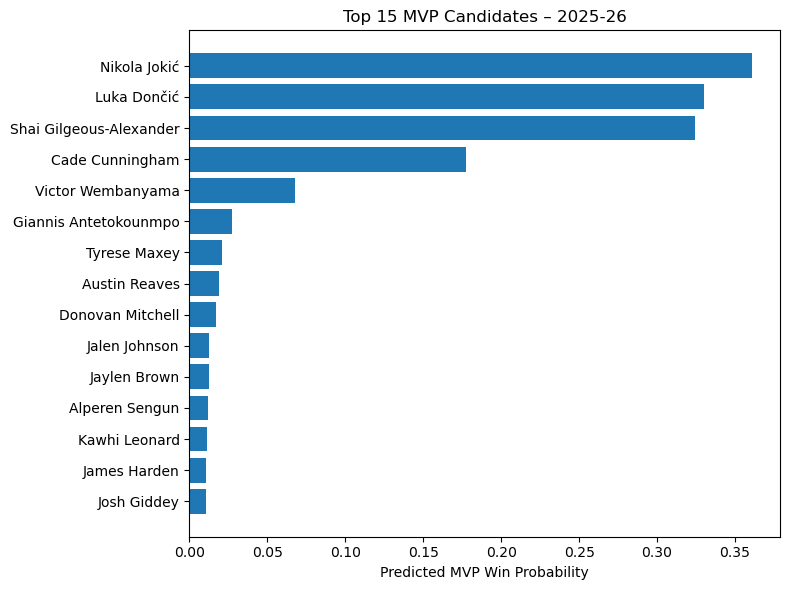

                 PLAYER_NAME  prob_linreg   prob_logreg  prob_rf  \
366             Nikola Jokić     0.065372  9.989632e-01    0.018   
321              Luka Dončić     0.060652  9.262482e-01    0.004   
426  Shai Gilgeous-Alexander     0.049749  9.102558e-01    0.012   
59           Cade Cunningham     0.041527  4.718969e-01    0.018   
471        Victor Wembanyama     0.036299  1.601519e-01    0.006   
159    Giannis Antetokounmpo     0.056445  2.286461e-02    0.002   
466             Tyrese Maxey     0.036387  2.470681e-02    0.002   
30             Austin Reaves     0.030621  2.663453e-02    0.000   
129         Donovan Mitchell     0.039984  5.147640e-03    0.006   
202            Jalen Johnson     0.035893  1.193139e-03    0.000   
227             Jaylen Brown     0.034819  1.393092e-04    0.002   
13            Alperen Sengun     0.029457  7.364511e-03    0.000   
278            Kawhi Leonard     0.032402  9.619121e-08    0.002   
212             James Harden     0.032693  9.131

In [33]:
# Visualize top MVP probabilities for 2025–26
if pred_df.empty:
    print("No prediction data for 2025–26, cannot plot probabilities.")
else:
    top_n = 15
    top_preds = pred_df_sorted.head(top_n)

    plt.figure(figsize=(8, 6))
    plt.barh(top_preds["PLAYER_NAME"], top_preds["prob_ensemble"])
    plt.xlabel("Predicted MVP Win Probability")
    plt.title(f"Top {top_n} MVP Candidates – {PREDICTION_SEASON}")
    plt.gca().invert_yaxis()  # best at top
    plt.tight_layout()
    plt.show()

    print(top_preds[["PLAYER_NAME", "prob_linreg", "prob_logreg", "prob_rf", "prob_ensemble"]])


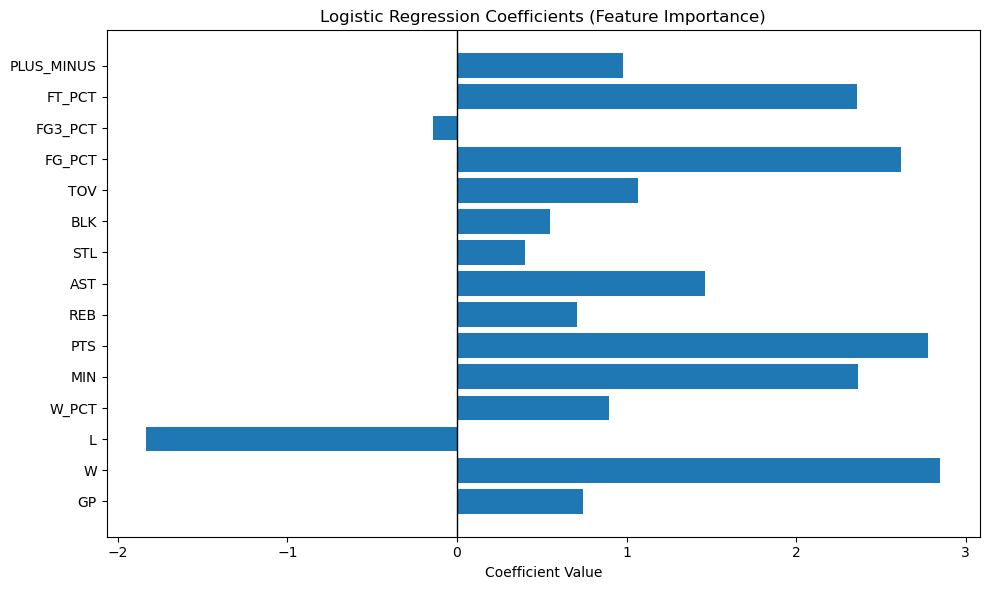

       feature      coef
1            W  2.849319
5          PTS  2.775137
11      FG_PCT  2.615315
4          MIN  2.365161
13      FT_PCT  2.359679
7          AST  1.459731
10         TOV  1.067321
14  PLUS_MINUS  0.980722
3        W_PCT  0.895531
0           GP  0.743572
6          REB  0.705662
9          BLK  0.550002
8          STL  0.400423
12     FG3_PCT -0.140668
2            L -1.832074


In [35]:
# Logistic Regression Feature Importance (Coefficients)
log_model = logreg_pipe.named_steps["model"]
scaler = logreg_pipe.named_steps["scaler"]

# Get standardized coefficient values
coef = log_model.coef_[0]
feature_names = feature_cols

plt.figure(figsize=(10, 6))
plt.barh(feature_names, coef)
plt.title("Logistic Regression Coefficients (Feature Importance)")
plt.xlabel("Coefficient Value")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

# Print sorted coefficients
coef_df = pd.DataFrame({"feature": feature_names, "coef": coef})
coef_df = coef_df.sort_values("coef", ascending=False)
print(coef_df)


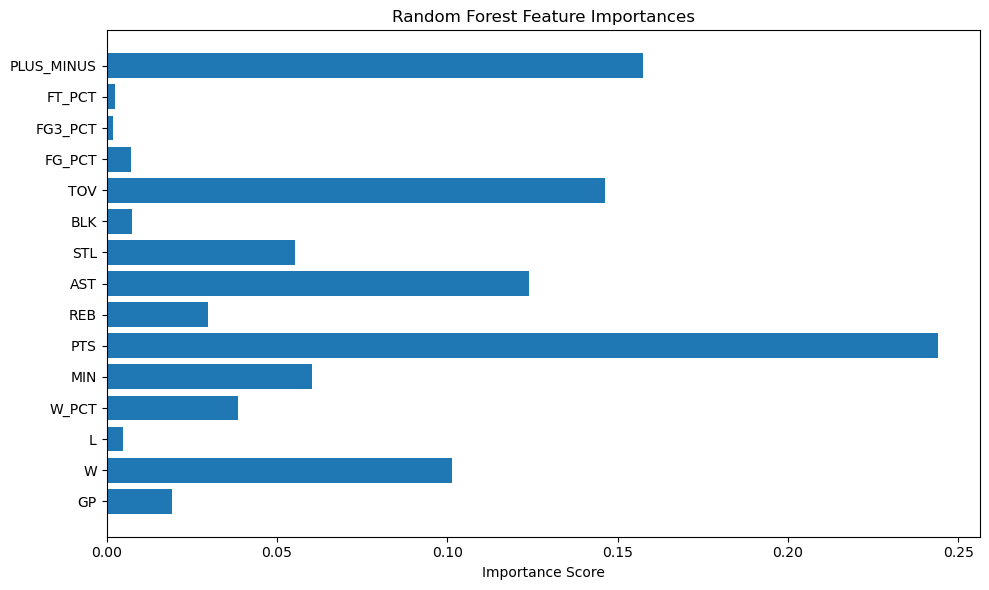

       feature  importance
5          PTS    0.244196
14  PLUS_MINUS    0.157483
10         TOV    0.146402
7          AST    0.124019
1            W    0.101316
4          MIN    0.060263
8          STL    0.055224
3        W_PCT    0.038599
6          REB    0.029694
0           GP    0.019243
9          BLK    0.007436
11      FG_PCT    0.007072
2            L    0.004718
13      FT_PCT    0.002331
12     FG3_PCT    0.002005


In [37]:
# Random Forest Feature Importance

importances = rf_model.feature_importances_
feature_names = feature_cols

plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# Print sorted importances
rf_imp = pd.DataFrame({"feature": feature_names, "importance": importances})
rf_imp = rf_imp.sort_values("importance", ascending=False)
print(rf_imp)
